In [2]:
# load the computed controller and certificate from the generted python file "sop_bounded_control_results_20260307_183051.py"
import sympy as sp

# from feasible_results.sop_bounded_control_ex1_debug_20260311_212221 import (
#     u_opt,
#     certificate_opt,
# )

from sop_bounded_control_ex1_debug_20260311_225347 import (
    u_opt,
    certificate_opt,
)


# reshape u_opt as a (n, 1) sympy matrix
u_opt = sp.Matrix(u_opt)

# extract all symbols from u_opt and certificate_opt
u_opt_symbols = u_opt.free_symbols
certificate_opt_symbols = certificate_opt.free_symbols

print("expression of u_opt")
print(u_opt[0])


print("\nexpression of certificate_opt")

print(certificate_opt)

print("Extracted symbols from u_opt:")
for sym in u_opt_symbols:
    print(sym)

print("\nExtracted symbols from certificate_opt:")
for sym in certificate_opt_symbols:
    print(sym)

expression of u_opt
9.81960911727072e-5*x1**8 + 0.0153475973007221*x1**7 + 0.000222454962476282*x1**6 + 0.00886934992989319*x1**5 + 0.000811643397659156*x1**4 - 0.00689512504602544*x1**3 - 0.000468472231575361*x1**2 - 1.99336681045141*x1 - x2*(0.19824*x1**7 + 27.111*x1**6 + 0.336822*x1**5 + 11.191*x1**4 + 0.81928*x1**3 - 5.22*x1**2 - 0.23644*x1 + 1.6739) + 4568699966963223*x2/1152921504606846976 + 8.62049139374928e-5

expression of certificate_opt
-x1**2 - (0.02478*x1**8 + 3.873*x1**7 + 0.056137*x1**6 + 2.2382*x1**5 + 0.20482*x1**4 - 1.74*x1**3 - 0.11822*x1**2 + 1.6739*x1 + x2 + 0.021754)**2/2 + 1
Extracted symbols from u_opt:
x1
x2

Extracted symbols from certificate_opt:
x1
x2


In [3]:
# define the system
x1, x2 = sp.symbols("x1 x2")
y1, y2 = sp.symbols("y1 y2", real=True)

f = sp.Matrix([x2, 0])
g = sp.Matrix([[0], [1]])

hx = sp.Matrix([x1])  # output is the projection of the state on the x1-x3 plane


# define the safe set and target set
# Define the safe set
safe_set = 1 - y1**2  # safe_set >= 0 inside safe set

# Define the target set
target_set = y1**2 - 0.01  # target_set <= 0 inside target set
# target_set = (
#     2 * ((y2 - 0.1) / 2) ** 2
#     + 3 * ((y1 + 0.4) / 3) ** 4
#     + (3 * y1 + 0.3) ** 2 * (4 * y2 + 0.2) ** 2
#     - 0.01
# )

print("Safe set:  ", safe_set)
print("Target set:", target_set)
print("f:", f)
print("g:", g)
print("hx:", hx)

Safe set:   1 - y1**2
Target set: y1**2 - 0.01
f: Matrix([[x2], [0]])
g: Matrix([[0], [1]])
hx: Matrix([[x1]])


In [10]:
# randomly sample some states that within the zero superlevel set of the certificate function
N_samples = 10000
# set the bound for the state sampling, in order to ease the visualization later, we set all v values to be 0, and theta values to be between -pi and pi
import numpy as np

# np.random.seed(4)

# min_bound = np.array([-1, -1, -1, -1]).reshape(-1, 1)  # (4, 1) for broadcasting
# max_bound = np.array([1, 1, 1, 1]).reshape(-1, 1)  # (4, 1) for broadcasting

# x_samples = np.random.uniform(low=min_bound, high=max_bound, size=(4, N_samples))
np.random.seed(4)  # set random seed for reproducing the result presented in the paper
x_samples = np.random.random((2, N_samples)) * 2 - 1
print("x_samples shape:", x_samples.shape)

# print the min and max for each state variable in the sampled states to verify the sampling
print("Min and max of sampled states:")
for i in range(x_samples.shape[0]):
    print(f"x{i+1}: min = {x_samples[i, :].min()}, max = {x_samples[i, :].max()}")

x_samples shape: (2, 10000)
Min and max of sampled states:
x1: min = -0.9995293045120786, max = 0.9995654181634741
x2: min = -0.9997454358862192, max = 0.9997878421498256


In [11]:
# construt a evaluatable function for the certificate using the obtained symbolic expression and the extracted symbols, in order to evaluate the certificate value for the sampled states and filter out the valid samples that satisfy the certificate condition
certificate_func = sp.lambdify([x1, x2], certificate_opt, "numpy")

# evaluate the certificate value for the sampled states
certificate_values = certificate_func(x_samples[0, :], x_samples[1, :])
print("certificate_values shape:", certificate_values.shape)

# construct a evaluatable function for the target set using the obtained symbolic expression and the extracted symbols, in order to evaluate the target set value for the sampled states and filter out the valid samples that satisfy the target set condition
target_set_x = target_set.subs({y1: hx[0]})
target_set_x_func = sp.lambdify([x1, x2], target_set_x, "numpy")
target_set_values = target_set_x_func(
    x_samples[0, :], x_samples[1, :]
)  # only use x1 and x2 for evaluating the target set condition since the output is the projection of the state on the x1-x2 plane
print("target_set_values shape:", target_set_values.shape)

# print the min and max of the certificate values for the sampled states
print("Min certificate value among sampled states:", np.min(certificate_values))
print("Max certificate value among sampled states:", np.max(certificate_values))

# filter out the valid samples that satisfy the certificate condition certificate >= 0 && not in target set (target_set > 0)
valid_indices = np.where((certificate_values >= 0) & (target_set_values > 0))[0]
x_samples_valid = x_samples[:, valid_indices]
# x_samples_valid = x_samples[:, :100]
x_samples_valid = x_samples_valid[
    :, :20
]  # only keep the first N_samples valid samples for visualization
print(
    "Number of valid samples that satisfy the certificate condition:",
    x_samples_valid.shape[1],
)

certificate_values shape: (10000,)
target_set_values shape: (10000,)
Min certificate value among sampled states: -24.61958750111726
Max certificate value among sampled states: 0.9996722064142348
Number of valid samples that satisfy the certificate condition: 20


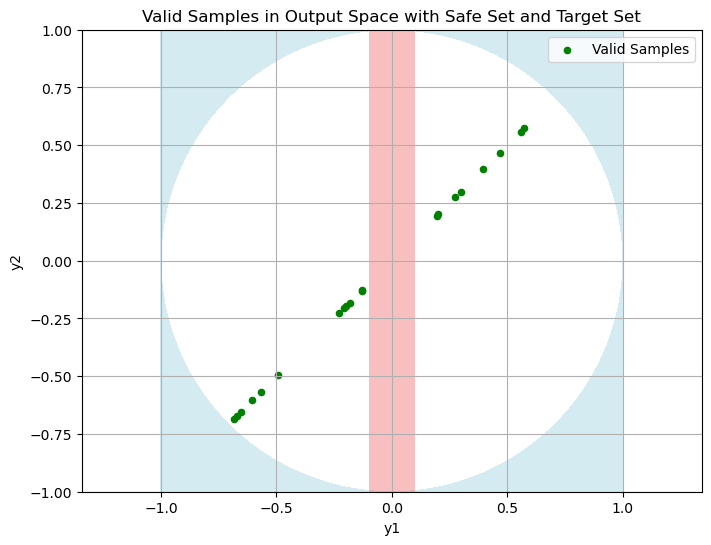

In [12]:
# visuazlie the valid samples in the output space to verify that they are indeed within the zero superlevel set of the certificate function, and also visualize the safe set and target set in the output space to verify that the valid samples are within the safe set and outside the target set
import matplotlib.pyplot as plt

# compute the output values for the valid samples
y_samples_valid = np.zeros((2, x_samples_valid.shape[1]))
for i in range(x_samples_valid.shape[1]):
    y_samples_valid[:, i] = (
        np.array(
            hx.subs(
                {
                    x1: x_samples_valid[0, i],
                    x2: x_samples_valid[1, i],
                }
            )
        )
        .astype(np.float64)
        .flatten()
    )


# create a grid for visualizing the safe set and target set
y1_grid = np.linspace(-1, 1, 100)
y2_grid = np.linspace(-1, 1, 100)
Y1, Y2 = np.meshgrid(y1_grid, y2_grid)
safe_set_values = (1 - Y1**2 - Y2**2).astype(
    np.float64
)  # evaluate the safe set function on the grid
# target_set_values = (
#     2 * ((Y2 - 0.1) / 2) ** 2
#     + 3 * ((Y1 + 0.4) / 3) ** 4
#     + (3 * Y1 + 0.3) ** 2 * (4 * Y2 + 0.2) ** 2
#     - 0.01
# ).astype(
#     np.float64
# )  # evaluate the target set function on the grid
target_set_values = (Y1**2 - 0.01).astype(
    np.float64
)  # evaluate the target set function on the grid

plt.figure(figsize=(8, 6))
plt.contourf(
    Y1,
    Y2,
    safe_set_values,
    levels=[-np.inf, 0],
    colors=["lightblue", "none"],
    alpha=0.5,
)
plt.contourf(
    Y1,
    Y2,
    target_set_values,
    levels=[-np.inf, 0],
    colors=["lightcoral", "none"],
    alpha=0.5,
)
plt.scatter(
    y_samples_valid[0, :],
    y_samples_valid[1, :],
    color="green",
    label="Valid Samples",
    s=20,
)
plt.xlabel("y1")
plt.ylabel("y2")
plt.title("Valid Samples in Output Space with Safe Set and Target Set")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

In [13]:
# get the closed-loop system dynamics under the obtained controller u_opt
print("u_opt:", u_opt)

# substitute the u_opt into the original system dynamics to get the closed-loop system dynamics
closed_loop_dynamics = f + g @ u_opt
print("Closed-loop system dynamics:", closed_loop_dynamics.T)
print("Closed-loop system dynamics shape:", closed_loop_dynamics.shape)

# then convert the closed-loop system dynamics into a numerical function that can be evaluated for the valid sampled states, in order to simulate the trajectories from the valid sampled initial states and verify whether they can reach the target set while avoiding the unsafe region
dyn_cl_f = sp.lambdify([x1, x2], closed_loop_dynamics, "numpy")

u_opt: Matrix([[9.81960911727072e-5*x1**8 + 0.0153475973007221*x1**7 + 0.000222454962476282*x1**6 + 0.00886934992989319*x1**5 + 0.000811643397659156*x1**4 - 0.00689512504602544*x1**3 - 0.000468472231575361*x1**2 - 1.99336681045141*x1 - x2*(0.19824*x1**7 + 27.111*x1**6 + 0.336822*x1**5 + 11.191*x1**4 + 0.81928*x1**3 - 5.22*x1**2 - 0.23644*x1 + 1.6739) + 4568699966963223*x2/1152921504606846976 + 8.62049139374928e-5]])
Closed-loop system dynamics: Matrix([[x2, 9.81960911727072e-5*x1**8 + 0.0153475973007221*x1**7 + 0.000222454962476282*x1**6 + 0.00886934992989319*x1**5 + 0.000811643397659156*x1**4 - 0.00689512504602544*x1**3 - 0.000468472231575361*x1**2 - 1.99336681045141*x1 - x2*(0.19824*x1**7 + 27.111*x1**6 + 0.336822*x1**5 + 11.191*x1**4 + 0.81928*x1**3 - 5.22*x1**2 - 0.23644*x1 + 1.6739) + 4568699966963223*x2/1152921504606846976 + 8.62049139374928e-5]])
Closed-loop system dynamics shape: (2, 1)


In [15]:
import numpy as np
from scipy.integrate import odeint


def simulate(dyn, x0, dt, N=3):  # simulate one step from given x0
    if x0.ndim == 1:
        x0 = x0.reshape(1, -1)
    assert x0.ndim == 2

    def ode_fx(x, t):
        x = x.reshape(x0.shape)
        y = dyn(*x.T).squeeze(axis=1).T
        return y.flatten()

    x1 = odeint(ode_fx, x0.flatten(), np.linspace(0, dt, N))[-1].reshape(x0.shape)

    return x1


hf = sp.lambdify([x1, x2], hx, "numpy")
phi_x = target_set.subs({y1: hx[0]})
phi_fx = sp.lambdify([x1, x2], phi_x, "numpy")

traj_x = []
traj_y = []

dt = 0.01

for i in range(x_samples_valid.shape[-1]):
    # for this point, simulate the trajectory until reach the target set
    x_cur = x_samples_valid[:, i].reshape(1, -1)
    y_cur = hf(*x_cur.T).squeeze(axis=1)

    this_traj_x = [x_cur]
    this_traj_y = [y_cur]

    to_continue = True

    this_phi_val = phi_fx(*x_cur.T)
    print(this_phi_val)

    to_continue = True if this_phi_val > 0 else False

    max_steps = 1000

    while to_continue:
        x_next = simulate(dyn_cl_f, x_cur, dt, 3)
        y_next = hf(*x_next.T).squeeze(axis=1)
        this_phi_val = phi_fx(*x_next.T).squeeze()
        to_continue = True if ((this_phi_val > 0) & (max_steps > 0)) else False

        this_traj_x.append(x_cur)
        this_traj_y.append(y_next)

        max_steps -= 1

        x_cur = x_next

        # print(len(this_traj_y))

    this_traj_x = np.stack(this_traj_x).squeeze(axis=1)
    this_traj_y = np.stack(this_traj_y).squeeze(axis=-1)

    print(this_traj_y.shape)

    traj_x.append(this_traj_x)
    traj_y.append(this_traj_y)

[0.14638675]
(106, 1)
[0.3124207]
(162, 1)
[0.23407085]
(72, 1)
[0.00700858]
(205, 1)
[0.30221927]
(135, 1)
[0.35557726]
(98, 1)
[0.44200815]
(80, 1)
[0.02789559]
(27, 1)
[0.0414643]
(22, 1)
[0.006309]
(6, 1)
[0.31788447]
(69, 1)
[0.41728337]
(74, 1)
[0.03059638]
(13, 1)
[0.20786521]
(50, 1)
[0.02353011]
(29, 1)
[0.45724496]
(142, 1)
[0.06574632]
(72, 1)
[0.02881259]
(27, 1)
[0.07976628]
(179, 1)
[0.03251844]
(19, 1)


IndexError: index 1 is out of bounds for axis 1 with size 1

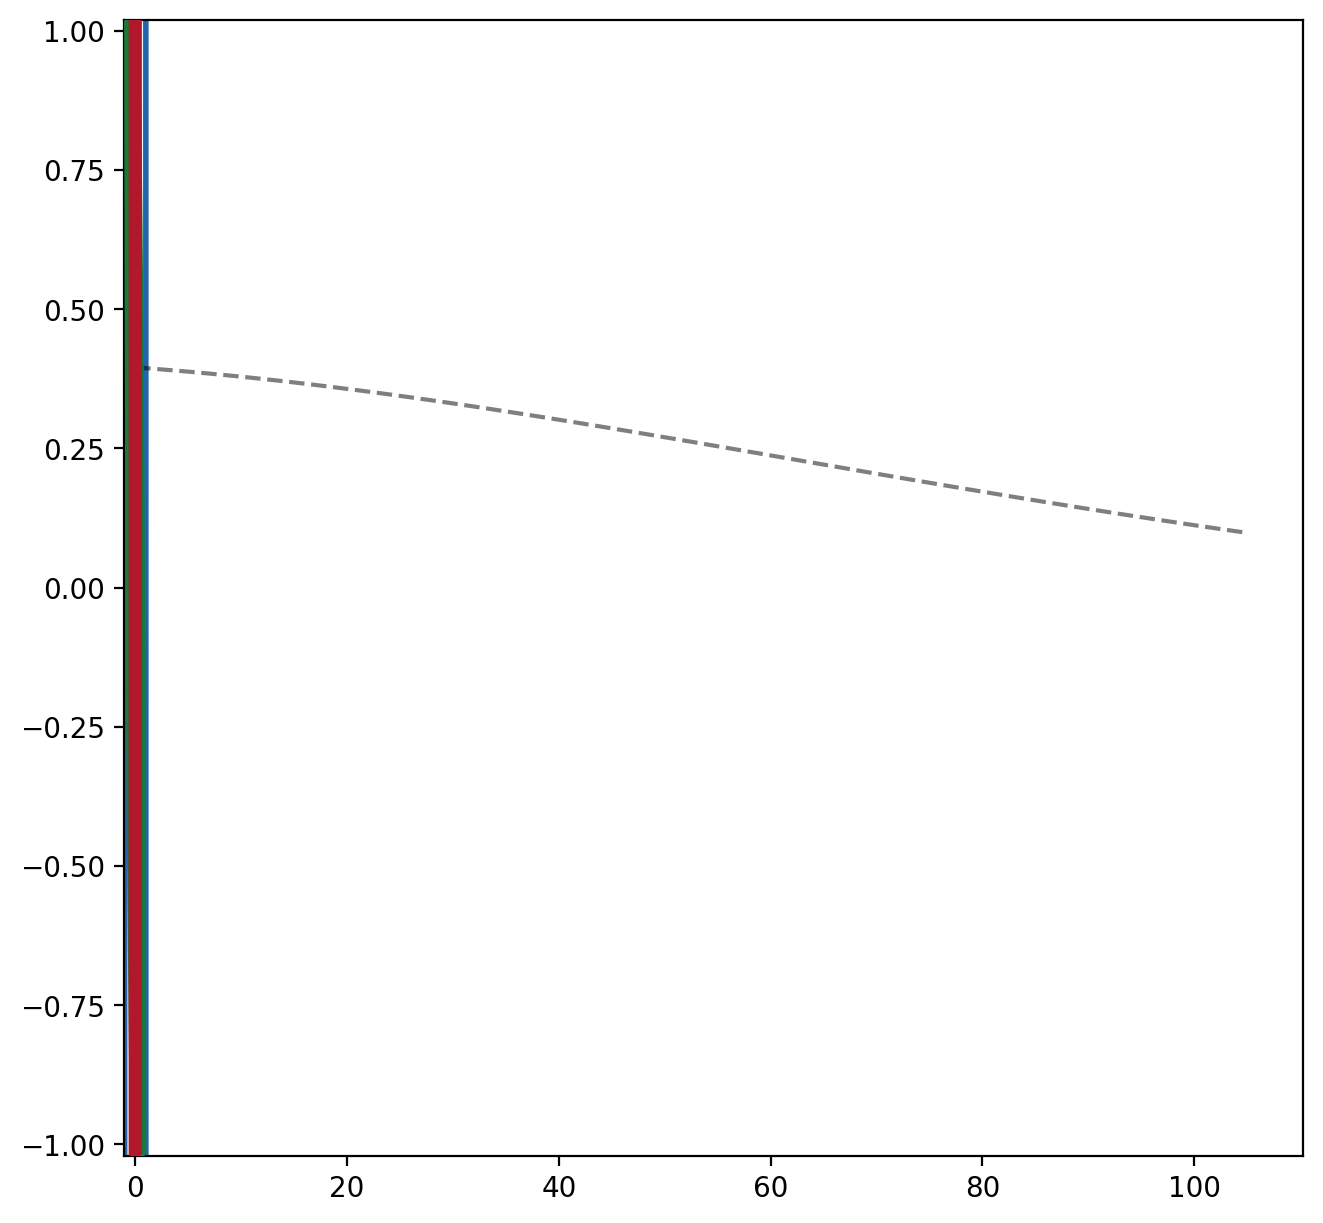

In [ ]:
import matplotlib.pyplot as plt
from functional import BetterColor

px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px, 600 * px), layout="constrained")
fig.set_dpi(200)

ny1 = np.linspace(-1.02, 1.02, 1000)
ny2 = np.linspace(-1.02, 1.02, 1000)

Y1, Y2 = np.meshgrid(ny1, ny2)
phi_fy = sp.lambdify([y1, y2], target_set, "numpy")
psi_fy = sp.lambdify([y1, y2], safe_set, "numpy")

Z_phi = phi_fy(Y1, Y2)
Z_psi = psi_fy(Y1, Y2)
Z_cert = certificate_func(Y1, Y2)

# vector field of the single-integrator system with k1 controller
# k1f = sp.lambdify(y, k1, "numpy")
# Z = k1f(Y1, Y2).squeeze()
# print(Z.shape, "z")
# ax.streamplot(
#     Y1,
#     Y2,
#     Z[0],
#     Z[1],
#     density=0.5,
#     # color="#404040",  # 中灰色调
#     # color="#2F4F4F",
#     color=BetterColor.gray0(0.7),
#     linewidth=1.5,
#     arrowstyle="->",
#     arrowsize=1.2,
# )

ax.contourf(
    Y1,
    Y2,
    Z_psi,
    levels=[0, +np.inf],
    colors=["#e6f2ff"],  # 极浅蓝
    # hatches=["..."],  # 点状图案
    alpha=0.3,
    zorder=1,
)

ax.contour(
    Y1,
    Y2,
    Z_psi,
    levels=[0],
    colors=["#2166ac"],  # 学术蓝
    linewidths=2,
    zorder=2,
)

ax.contourf(
    Y1,
    Y2,
    Z_phi,
    levels=[-np.inf, 0],
    colors=["#fee0d2"],  # 浅珊瑚色
    # hatches=["////"],  # 斜线图案
    alpha=1,
    zorder=100,
)
ax.contour(
    Y1,
    Y2,
    Z_phi,
    levels=[0],
    colors=["#b2182b"],  # 深红色
    linewidths=4,
    zorder=101,
)

ax.contourf(
    Y1,
    Y2,
    Z_cert,
    levels=[0, +np.inf],
    colors=["#d9f0d9"],  # 极浅绿色
    # hatches=["...."],  # 点状图案
    alpha=0.5,
    zorder=50,
)
ax.contour(
    Y1,
    Y2,
    Z_cert,
    levels=[0],
    colors=["#1b7837"],  # 学术绿
    linewidths=2,
    zorder=51,
)


line_style = {
    # "color": "#404040",  # 改用学术灰代替纯黑
    "color": "#2166ac",
    "linestyle": "-",  # 使用实线代替点划线
    "alpha": 0.2,
    "linewidth": 0.5,
    "solid_capstyle": "round",
}

# plot each output trajectory

for i in range(len(traj_y)):
    this_traj_y = traj_y[i]
    # trajectory
    plt.plot(
        this_traj_y[:, 0],
        # this_traj_y[:, 1],
        # **line_style,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        zorder=5,
        # "red",
        # linewidth=1.0,
        # alpha=0.4,
        # zorder=2,
    )
    # start point
    # plt.scatter(
    #     this_traj_y[0, 0], this_traj_y[0, 1], s=2, c="black", alpha=0.3, zorder=3
    # )
    # plt.scatter(
    #     this_traj_y[0, 0],
    #     this_traj_y[0, 1],
    #     s=50,
    #     # c="#d73027",  # IEEE红
    #     c=BetterColor.orange3(),
    #     # marker="^",  # 三角形
    #     # edgecolor="w",  # 白边
    #     linewidth=0.3,
    #     zorder=20,
    # )
    # end point
    # plt.scatter(this_traj_y[-1, 0], this_traj_y[-1, 1], s=2.5, c="red", zorder=3)
    # plt.scatter(
    #     this_traj_y[-1, 0],
    #     # this_traj_y[-1, 1],
    #     s=50,
    #     linewidth=1,
    #     # c="#313695",  # 深蓝
    #     # c="#8B008B",
    #     # c="#4daf4a",
    #     c=BetterColor.green0(),
    #     # edgecolors="#984ea3",
    #     # marker="o",  # 圆形
    #     # marker=(5, 1, 0),
    #     marker="x",
    #     # edgecolor="#ffffbf",  # 浅黄边
    #     # linewidth=0.4,
    #     zorder=200,
    # )

this_fontsize = 35

ax.text(0.5, -0.75, "$\mathcal{C}$", zorder=1000, fontsize=this_fontsize)
ax.text(-0.27, -0.05, "$\mathcal{X}^r$", zorder=1000, fontsize=this_fontsize)

ax.xaxis.set_tick_params(labelsize=20, width=1)
ax.yaxis.set_tick_params(labelsize=20, width=1)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))
plt.xlabel("$y_1$", fontsize=this_fontsize - 5)
plt.ylabel("$y_2$", fontsize=this_fontsize - 5)

plt.show()